# Phase 8b: Precursor-Augmented Forecasting Models

**Goal:** Test whether the geomagnetic aa-index and polar-field precursors built in Phase 8 actually
improve the existing forecasting models.

Two experiments:

1. **Static amplitude/timing models (Phase 6 architecture)** — add `aa_pre12` / `aa_pre24` /
   `aa_at_min` to the curated Phase 6 feature set (RF + LOCO CV) and compare MAE for
   `Peak_Sunspot_Number` and `Rise_Time_months`.
2. **Running timing model (Phase 7 v2 architecture)** — add `aa_pre24` as a per-cycle constant
   feature to the month-by-month RF model and check whether it helps the weak **early pre-peak
   window (T < 24m)**.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

# Reference results from earlier phases
PHASE4_MAG_MAE     = 26.6    # Phase 3 RF, Peak Sunspot Number
PHASE4_TIM_MAE     = 5.96    # Phase 4 RF-36m, Rise_Time_months
PHASE6_MAG_MAE     = 28.51   # Phase 6 RF, all features
PHASE6_TIM_MAE     = 6.56    # Phase 6 RF, all features
PHASE6_CUR_MAG_MAE = 28.19   # Phase 6 RF, curated features
PHASE6_CUR_TIM_MAE = 6.66    # Phase 6 RF, curated features
PHASE7V2_OVERALL_MAE = 4.39
PHASE7V2_PRE_MAE     = 8.08
PHASE7V2_POST_MAE    = 2.25
PHASE7V2_SIGN_ACC    = 93.9
PHASE7V2_POSTDETECT  = 95.4

cycle_db = pd.read_csv(DATA_DIR / 'Cycle_Database_completed.csv')
cycle_db['Start_Date'] = pd.to_datetime(cycle_db['Start_Date'])
cycle_db['Peak_Date']  = pd.to_datetime(cycle_db['Peak_Date'])
cycle_db['End_Date']   = pd.to_datetime(cycle_db['End_Date'])

precursors = pd.read_csv(DATA_DIR / 'Cycle_Database_with_precursors.csv',
                          usecols=['Cycle_ID', 'aa_at_min', 'aa_pre12', 'aa_pre24',
                                   'polar_field_at_min', 'polar_field_abs_at_min'])

print(f"Cycle DB    : {cycle_db.shape}")
print(f"Precursors  : {precursors.shape}")
print(f"aa_pre24 coverage: {precursors['aa_pre24'].notna().sum()} / {len(precursors)} cycles")


Cycle DB    : (24, 58)
Precursors  : (24, 6)
aa_pre24 coverage: 11 / 24 cycles


## 2. Recreate Phase 6 Kp / F10.7 & Polar Field Window Features

In [2]:
# --- Kp / F10.7 monthly (same parsing as Phase 6) ---
KP_COLS = ['YYYY','MM','DD','days','days_m','Bsr','dB',
           'Kp1','Kp2','Kp3','Kp4','Kp5','Kp6','Kp7','Kp8',
           'ap1','ap2','ap3','ap4','ap5','ap6','ap7','ap8',
           'Ap','SN','F107obs','F107adj','D']

rows = []
with open(DATA_DIR / 'kp_monthly.txt') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        if len(parts) == 28:
            rows.append(parts)

kp_raw = pd.DataFrame(rows, columns=KP_COLS)
kp_raw['YYYY'] = kp_raw['YYYY'].astype(int)
kp_raw['MM']   = kp_raw['MM'].astype(int)
kp_raw['Ap']      = pd.to_numeric(kp_raw['Ap'],      errors='coerce').replace(-1,   np.nan)
kp_raw['F107obs'] = pd.to_numeric(kp_raw['F107obs'], errors='coerce').replace(-1.0, np.nan)

kp_monthly = (kp_raw.groupby(['YYYY','MM'])
              .agg(Ap_mean=('Ap','mean'), F107_mean=('F107obs','mean'))
              .reset_index())
kp_monthly['date'] = pd.to_datetime(dict(year=kp_monthly['YYYY'], month=kp_monthly['MM'], day=1))

# --- Polar field monthly (same parsing as Phase 6) ---
pf_rows = []
with open(DATA_DIR / 'polar_field.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = re.match(r'(\d{4}):(\d{2}):(\d{2})_.*?\s+([-\d]+)N\s+([-\d]+)S\s+([-\d]+)Avg', line)
        if m:
            yr, mo, dy, N, S, Avg = m.groups()
            pf_rows.append({'year': int(yr), 'month': int(mo),
                            'PF_N': float(N), 'PF_S': float(S), 'PF_Avg': abs(float(Avg))})

pf_raw = pd.DataFrame(pf_rows)
pf_monthly = (pf_raw.groupby(['year','month'])
              .agg(PF_N=('PF_N','mean'), PF_S=('PF_S','mean'), PF_Avg=('PF_Avg','mean'))
              .reset_index())
pf_monthly['date'] = pd.to_datetime(dict(year=pf_monthly['year'], month=pf_monthly['month'], day=1))

print(f"Kp/F10.7 monthly   : {len(kp_monthly)} rows ({kp_monthly['date'].min().date()} - {kp_monthly['date'].max().date()})")
print(f"Polar field monthly: {len(pf_monthly)} rows ({pf_monthly['date'].min().date()} - {pf_monthly['date'].max().date()})")


Kp/F10.7 monthly   : 1134 rows (1932-01-01 - 2026-06-01)
Polar field monthly: 592 rows (1976-05-01 - 2025-12-01)


In [3]:
def extract_window_features(start_date, monthly_df, value_cols, windows=(36,)):
    feats = {}
    for w in windows:
        end = start_date + pd.DateOffset(months=w)
        mask = (monthly_df['date'] >= start_date) & (monthly_df['date'] < end)
        sub = monthly_df[mask]
        for col in value_cols:
            vals = sub[col].dropna().values
            pfx = f"{col}_w{w}"
            feats[f"{pfx}_mean"] = float(vals.mean()) if len(vals) >= max(3, w // 4) else np.nan
    return feats

def get_pf_at_minimum(start_date, pf_df, window_months=3):
    lo = start_date - pd.DateOffset(months=window_months)
    hi = start_date + pd.DateOffset(months=window_months)
    sub = pf_df[(pf_df['date'] >= lo) & (pf_df['date'] <= hi)]
    return {'PF_Avg_at_min': float(sub['PF_Avg'].mean()) if not sub.empty else np.nan}

kp_feat_rows, pf_feat_rows = [], []
for _, row in cycle_db.iterrows():
    f1 = extract_window_features(row['Start_Date'], kp_monthly, ['Ap_mean', 'F107_mean'], windows=(36,))
    f1['Cycle_ID'] = row['Cycle_ID']
    kp_feat_rows.append(f1)

    f2 = get_pf_at_minimum(row['Start_Date'], pf_monthly)
    f2['Cycle_ID'] = row['Cycle_ID']
    pf_feat_rows.append(f2)

kp_features = pd.DataFrame(kp_feat_rows)
pf_features = pd.DataFrame(pf_feat_rows)

print("Recreated Phase 6 curated features:",
      [c for c in kp_features.columns if c != 'Cycle_ID'] + [c for c in pf_features.columns if c != 'Cycle_ID'])


Recreated Phase 6 curated features: ['Ap_mean_w36_mean', 'F107_mean_w36_mean', 'PF_Avg_at_min']


## 3. Build Extended Feature Matrix (Phase 6 + Phase 8 Precursors)

In [4]:
BASE_FEATS = [c for c in cycle_db.columns if c.startswith('w36_') and c != 'w36_months_available']

PHASE6_CURATED_NEW = ['PF_Avg_at_min', 'F107_mean_w36_mean', 'Ap_mean_w36_mean']
PHASE8_NEW         = ['aa_pre12', 'aa_pre24', 'aa_at_min']

ext_db = (cycle_db
          .merge(kp_features, on='Cycle_ID')
          .merge(pf_features, on='Cycle_ID')
          .merge(precursors[['Cycle_ID'] + PHASE8_NEW], on='Cycle_ID'))

CURATED_P6 = BASE_FEATS + PHASE6_CURATED_NEW
CURATED_P8 = CURATED_P6 + PHASE8_NEW

print(f"Base (w36) features      : {len(BASE_FEATS)}")
print(f"Phase 6 curated additions: {PHASE6_CURATED_NEW}")
print(f"Phase 8 new aa additions : {PHASE8_NEW}")
print(f"\nFeature set sizes -> Phase 6 curated: {len(CURATED_P6)}  |  Phase 8b curated: {len(CURATED_P8)}")

print("\naa precursor NaN % (cycles missing aa coverage):")
print((ext_db[PHASE8_NEW].isna().mean() * 100).round(1))


Base (w36) features      : 14
Phase 6 curated additions: ['PF_Avg_at_min', 'F107_mean_w36_mean', 'Ap_mean_w36_mean']
Phase 8 new aa additions : ['aa_pre12', 'aa_pre24', 'aa_at_min']

Feature set sizes -> Phase 6 curated: 17  |  Phase 8b curated: 20

aa precursor NaN % (cycles missing aa coverage):
aa_pre12     54.2
aa_pre24     54.2
aa_at_min    54.2
dtype: float64


## 4. LOCO CV Setup

In [5]:
def rf_fn():
    return RandomForestRegressor(n_estimators=300, random_state=SEED)

def ridge_fn():
    return Ridge(alpha=10)

def loco_cv(df, features, target, model_fn, seed=SEED):
    """Leave-One-Cycle-Out CV with imputation + scaling fit on train fold only."""
    records = []
    for test_id in df['Cycle_ID'].tolist():
        tr = df[df['Cycle_ID'] != test_id]
        te = df[df['Cycle_ID'] == test_id]

        X_tr, y_tr = tr[features].values, tr[target].values
        X_te, y_te = te[features].values, float(te[target].values[0])

        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        sc = RobustScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        mdl = model_fn()
        mdl.fit(X_tr, y_tr)
        y_pred = float(mdl.predict(X_te)[0])

        records.append({'Cycle_ID': test_id, 'y_true': y_te, 'y_pred': y_pred, 'error': y_pred - y_te})
    return pd.DataFrame(records)

print("LOCO CV function ready.")


LOCO CV function ready.


## 5. Magnitude Prediction (Peak Sunspot Number)

In [6]:
res_mag_p6 = loco_cv(ext_db, CURATED_P6, 'Peak_Sunspot_Number', rf_fn)
res_mag_p8 = loco_cv(ext_db, CURATED_P8, 'Peak_Sunspot_Number', rf_fn)

mae_mag_p6 = res_mag_p6['error'].abs().mean()
mae_mag_p8 = res_mag_p8['error'].abs().mean()

print("-- Magnitude (Peak Sunspot Number) LOCO CV --")
print(f"  Phase 4 baseline (Ridge w36)         : MAE = {PHASE4_MAG_MAE:.2f}")
print(f"  Phase 6 RF (curated, reported)       : MAE = {PHASE6_CUR_MAG_MAE:.2f}")
print(f"  Phase 6 RF (curated, recomputed here): MAE = {mae_mag_p6:.2f}")
print(f"  Phase 8b RF (curated + aa precursors): MAE = {mae_mag_p8:.2f}")
print(f"\n  Delta vs Phase 6 curated (recomputed): {mae_mag_p6 - mae_mag_p8:+.2f}  (positive = improvement)")


-- Magnitude (Peak Sunspot Number) LOCO CV --
  Phase 4 baseline (Ridge w36)         : MAE = 26.60
  Phase 6 RF (curated, reported)       : MAE = 28.19
  Phase 6 RF (curated, recomputed here): MAE = 28.19
  Phase 8b RF (curated + aa precursors): MAE = 29.06

  Delta vs Phase 6 curated (recomputed): -0.87  (positive = improvement)


## 6. Timing Prediction (Rise Time, months)

In [7]:
res_tim_p6 = loco_cv(ext_db, CURATED_P6, 'Rise_Time_months', rf_fn)
res_tim_p8 = loco_cv(ext_db, CURATED_P8, 'Rise_Time_months', rf_fn)

mae_tim_p6 = res_tim_p6['error'].abs().mean()
mae_tim_p8 = res_tim_p8['error'].abs().mean()

print("-- Timing (Rise_Time_months) LOCO CV --")
print(f"  Phase 4 baseline (RF w36)            : MAE = {PHASE4_TIM_MAE:.2f}")
print(f"  Phase 6 RF (curated, reported)       : MAE = {PHASE6_CUR_TIM_MAE:.2f}")
print(f"  Phase 6 RF (curated, recomputed here): MAE = {mae_tim_p6:.2f}")
print(f"  Phase 8b RF (curated + aa precursors): MAE = {mae_tim_p8:.2f}")
print(f"\n  Delta vs Phase 6 curated (recomputed): {mae_tim_p6 - mae_tim_p8:+.2f}  (positive = improvement)")


-- Timing (Rise_Time_months) LOCO CV --
  Phase 4 baseline (RF w36)            : MAE = 5.96
  Phase 6 RF (curated, reported)       : MAE = 6.66
  Phase 6 RF (curated, recomputed here): MAE = 6.66
  Phase 8b RF (curated + aa precursors): MAE = 6.63

  Delta vs Phase 6 curated (recomputed): +0.03  (positive = improvement)


## 7. Feature Importance (Phase 8b Timing Model)

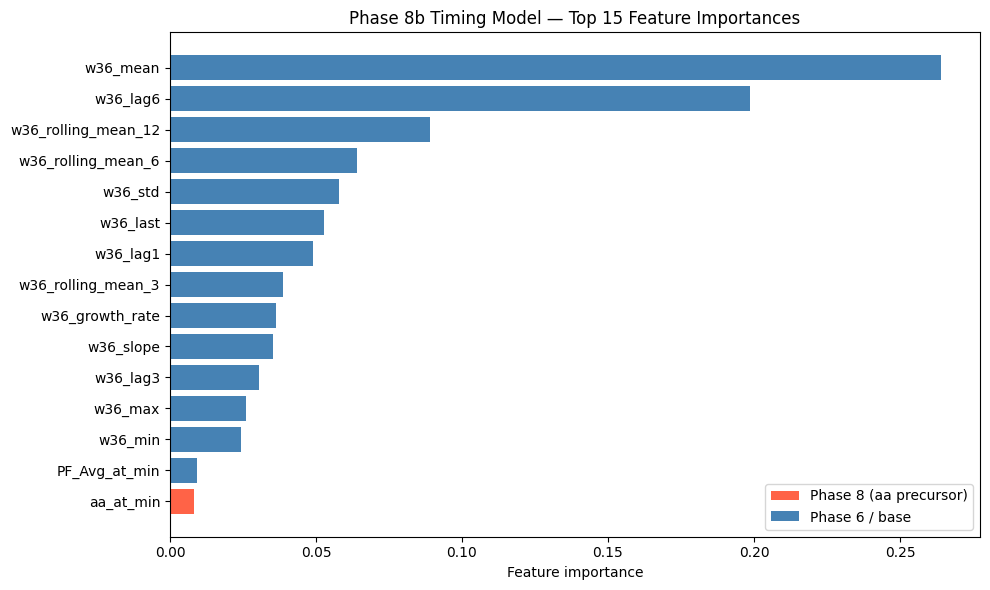

w36_mean               0.2642
w36_lag6               0.1987
w36_rolling_mean_12    0.0890
w36_rolling_mean_6     0.0641
w36_std                0.0578
w36_last               0.0526
w36_lag1               0.0490
w36_rolling_mean_3     0.0387
w36_growth_rate        0.0363
w36_slope              0.0352
dtype: float64


In [8]:
imp_full = SimpleImputer(strategy='median')
sc_full  = RobustScaler()
X_all = sc_full.fit_transform(imp_full.fit_transform(ext_db[CURATED_P8].values))
y_tim = ext_db['Rise_Time_months'].values

rf_full = RandomForestRegressor(n_estimators=500, random_state=SEED)
rf_full.fit(X_all, y_tim)

feat_imp = pd.Series(rf_full.feature_importances_, index=CURATED_P8).sort_values(ascending=False)

colors = ['tomato' if f in PHASE8_NEW else 'steelblue' for f in feat_imp.index[:15]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp.index[:15][::-1], feat_imp.values[:15][::-1], color=colors[::-1])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='tomato', label='Phase 8 (aa precursor)'),
                    Patch(facecolor='steelblue', label='Phase 6 / base')], loc='lower right')
ax.set_xlabel('Feature importance')
ax.set_title('Phase 8b Timing Model — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p8b_feature_importance.png', dpi=120)
plt.show()

print(feat_imp.head(10).round(4))


## 8. Phase 7 v2 + aa Precursor — Running Timing Forecast

We add `aa_pre24` (geomagnetic activity 24 months before the cycle's minimum) as a **per-cycle
constant feature** to the Phase 7 v2 month-by-month RF model and re-run LOCO CV. Since `aa_pre24`
is only available for SC14-SC24, missing values are imputed with the **training-fold median**
(no leakage from the held-out cycle).


In [9]:
sn_raw = pd.read_csv(
    DATA_DIR / 'SN_m_tot_V2.0.csv', sep=';', header=None,
    names=['Year','Month','FracYear','SN','StdDev','Nobs','Definitive']
)
sn_raw = sn_raw[sn_raw['SN'] >= 0].copy()
sn_raw['Date'] = pd.to_datetime({'year': sn_raw['Year'], 'month': sn_raw['Month'], 'day': 1})
sn_raw = sn_raw.sort_values('Date').reset_index(drop=True)

cyc = cycle_db.copy()
MIN_T = 6

def get_cycle_ssn(start_date, end_date):
    mask = (sn_raw['Date'] >= start_date) & (sn_raw['Date'] < end_date)
    return sn_raw.loc[mask, 'SN'].values

def trailing_smooth(arr, w=13):
    result = np.empty(len(arr))
    for i in range(len(arr)):
        result[i] = arr[max(0, i - w + 1):i + 1].mean()
    return result

def slope_fit(arr):
    if len(arr) < 2:
        return 0.0
    return np.polyfit(np.arange(len(arr)), arr, 1)[0]

FEATURE_COLS_V2 = [
    't_elapsed', 'sn_smooth_current', 'sn_smooth_roll3', 'sn_smooth_roll6', 'sn_smooth_roll12',
    'sn_smooth_max', 'sn_smooth_frac_of_max', 'months_since_smooth_max',
    'sn_smooth_slope_6', 'sn_smooth_slope_12', 'sn_smooth_accel', 'sn_smooth_std_12',
    'sn_still_rising', 'post_peak_months',
]

def extract_features_v2(ssn_raw_series, T):
    if T < MIN_T or T >= len(ssn_raw_series):
        return None
    raw    = np.array(ssn_raw_series[:T + 1], dtype=float)
    smooth = trailing_smooth(raw)
    cur    = smooth[-1]
    roll3  = smooth[-3:].mean()  if len(smooth) >= 3  else smooth.mean()
    roll6  = smooth[-6:].mean()  if len(smooth) >= 6  else smooth.mean()
    roll12 = smooth[-12:].mean() if len(smooth) >= 12 else smooth.mean()
    sm_max  = smooth.max()
    idx_max = int(smooth.argmax())
    msm     = T - idx_max
    frac    = cur / max(sm_max, 1.0)
    sl6   = slope_fit(smooth[-6:])  if len(smooth) >= 6  else slope_fit(smooth)
    sl12  = slope_fit(smooth[-12:]) if len(smooth) >= 12 else slope_fit(smooth)
    accel = sl6 - sl12
    std12 = smooth[-12:].std() if len(smooth) >= 12 else smooth.std()
    rising  = 1 if sl6 > 0 else 0
    post_pk = msm if rising == 0 else 0
    return {
        't_elapsed': T, 'sn_smooth_current': cur,
        'sn_smooth_roll3': roll3, 'sn_smooth_roll6': roll6, 'sn_smooth_roll12': roll12,
        'sn_smooth_max': sm_max, 'sn_smooth_frac_of_max': frac,
        'months_since_smooth_max': msm,
        'sn_smooth_slope_6': sl6, 'sn_smooth_slope_12': sl12,
        'sn_smooth_accel': accel, 'sn_smooth_std_12': std12,
        'sn_still_rising': rising, 'post_peak_months': post_pk,
    }

aa_lookup = precursors.set_index('Cycle_ID')['aa_pre24'].to_dict()

records = []
for _, row in cyc.iterrows():
    cid   = int(row['Cycle_ID'])
    start = row['Start_Date']
    rise  = float(row['Rise_Time_months'])
    end   = row['End_Date'] if pd.notna(row['End_Date']) else (start + pd.DateOffset(months=int(rise * 2)))
    ssn   = get_cycle_ssn(start, end)
    for T in range(MIN_T, len(ssn)):
        feats = extract_features_v2(ssn, T)
        if feats is None:
            continue
        feats['Cycle_ID']       = cid
        feats['months_to_peak'] = rise - T
        feats['pre_peak']       = 1 if T < rise else 0
        feats['aa_pre24']       = aa_lookup.get(cid, np.nan)
        records.append(feats)

df_v2 = pd.DataFrame(records)
print(f"Dataset: {len(df_v2):,} samples (SC1-SC24)")
print(f"Cycles with aa_pre24 available: {df_v2.groupby('Cycle_ID')['aa_pre24'].first().notna().sum()} / 24")


Dataset: 3,034 samples (SC1-SC24)
Cycles with aa_pre24 available: 11 / 24


In [10]:
FEATURE_COLS_V2_AA = FEATURE_COLS_V2 + ['aa_pre24']

def run_loco_cv_v2(df, feature_cols, target_col='months_to_peak', seed=SEED):
    results = []
    for held_out in sorted(df['Cycle_ID'].unique()):
        train = df[df['Cycle_ID'] != held_out].copy()
        test  = df[df['Cycle_ID'] == held_out].copy()

        if 'aa_pre24' in feature_cols:
            med = train['aa_pre24'].median()
            train['aa_pre24'] = train['aa_pre24'].fillna(med)
            test['aa_pre24']  = test['aa_pre24'].fillna(med)

        model = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=seed)
        model.fit(train[feature_cols].values, train[target_col].values)
        y_pred = model.predict(test[feature_cols].values)
        y_true = test[target_col].values
        for i in range(len(y_true)):
            results.append({
                'Cycle_ID': held_out, 't_elapsed': test['t_elapsed'].values[i],
                'pre_peak': test['pre_peak'].values[i],
                'y_true': y_true[i], 'y_pred': y_pred[i],
                'abs_error': abs(y_true[i] - y_pred[i]),
                'signed_error': y_pred[i] - y_true[i],
            })
    return pd.DataFrame(results)

def summarize(cv, label):
    pre  = cv[cv['pre_peak'] == 1]
    post = cv[cv['pre_peak'] == 0]
    sign_acc    = (np.sign(cv['y_pred']) == np.sign(cv['y_true'])).mean() * 100
    post_detect = (post['y_pred'] < 0).mean() * 100
    print(f"{label:32s} Overall={cv['abs_error'].mean():.2f}  Pre={pre['abs_error'].mean():.2f}  "
          f"Post={post['abs_error'].mean():.2f}  SignAcc={sign_acc:.1f}%  PostDetect={post_detect:.1f}%")
    return cv['abs_error'].mean(), pre['abs_error'].mean(), post['abs_error'].mean(), sign_acc, post_detect

print("Running Phase 8b LOCO CV (24 folds)...\n")
cv_v2_base = run_loco_cv_v2(df_v2, FEATURE_COLS_V2)
cv_v2_aa   = run_loco_cv_v2(df_v2, FEATURE_COLS_V2_AA)

print(f"{'Phase 7v2 (reported)':32s} Overall={PHASE7V2_OVERALL_MAE}  Pre={PHASE7V2_PRE_MAE}  "
      f"Post={PHASE7V2_POST_MAE}  SignAcc={PHASE7V2_SIGN_ACC}%  PostDetect={PHASE7V2_POSTDETECT}%")
summarize(cv_v2_base, "Phase 8b reproduction (no aa)")
summarize(cv_v2_aa,   "Phase 8b + aa_pre24")


Running Phase 8b LOCO CV (24 folds)...

Phase 7v2 (reported)             Overall=4.39  Pre=8.08  Post=2.25  SignAcc=93.9%  PostDetect=95.4%
Phase 8b reproduction (no aa)    Overall=4.39  Pre=8.08  Post=2.25  SignAcc=93.9%  PostDetect=95.4%
Phase 8b + aa_pre24              Overall=4.47  Pre=8.24  Post=2.29  SignAcc=93.5%  PostDetect=95.2%


(np.float64(4.473259250105972),
 np.float64(8.24068426966777),
 np.float64(2.2873678585477193),
 np.float64(93.5398813447594),
 np.float64(95.15625))

Early pre-peak (T < 24m) MAE:
  No aa (reproduction)    : MAE = 8.28m  (n=432)
  + aa_pre24              : MAE = 8.83m  (n=432)


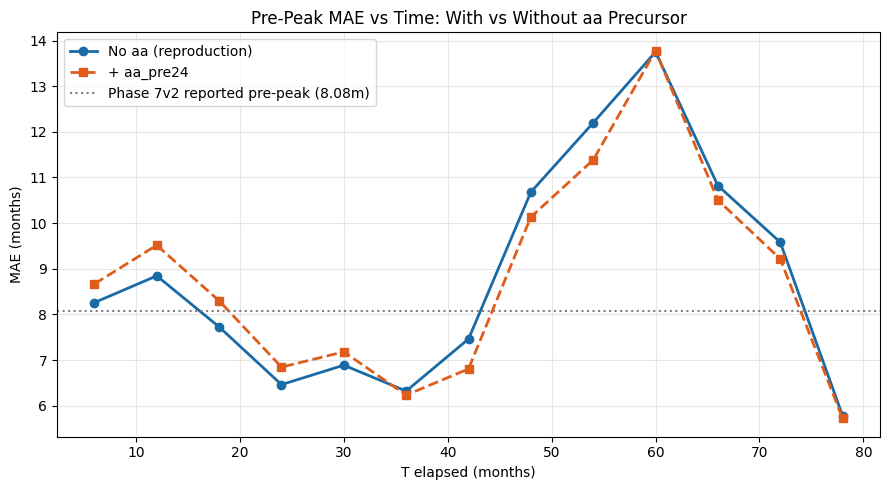

Saved plots/p8b_prepeak_mae_comparison.png


In [11]:
# Focus on the early pre-peak window (T < 24m), the weakest part of Phase 7 v2
print("Early pre-peak (T < 24m) MAE:")
for label, cv in [('No aa (reproduction)', cv_v2_base), ('+ aa_pre24', cv_v2_aa)]:
    early = cv[(cv['pre_peak'] == 1) & (cv['t_elapsed'] < 24)]
    print(f"  {label:24s}: MAE = {early['abs_error'].mean():.2f}m  (n={len(early)})")

# MAE(T) curve comparison, pre-peak only
for cv in (cv_v2_base, cv_v2_aa):
    cv['T_bin'] = (cv['t_elapsed'] // 6) * 6

mae_base = cv_v2_base[cv_v2_base['pre_peak'] == 1].groupby('T_bin')['abs_error'].mean()
mae_aa   = cv_v2_aa[cv_v2_aa['pre_peak'] == 1].groupby('T_bin')['abs_error'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mae_base.index, mae_base.values, 'o-', color='#1a6aa5', lw=2, label='No aa (reproduction)')
ax.plot(mae_aa.index,   mae_aa.values,   's--', color='#e05c1a', lw=2, label='+ aa_pre24')
ax.axhline(PHASE7V2_PRE_MAE, color='gray', ls=':', lw=1.5, label=f'Phase 7v2 reported pre-peak ({PHASE7V2_PRE_MAE}m)')
ax.set_xlabel('T elapsed (months)')
ax.set_ylabel('MAE (months)')
ax.set_title('Pre-Peak MAE vs Time: With vs Without aa Precursor')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p8b_prepeak_mae_comparison.png', dpi=120)
plt.show()
print("Saved plots/p8b_prepeak_mae_comparison.png")


## 9. Results Summary & Next Steps

### Static models (Phase 6 architecture, LOCO CV, RF)

| Model | Mag MAE | Tim MAE |
| --- | --- | --- |
| Phase 4 baseline (RF/Ridge w36) | 26.6 | 5.96 |
| Phase 6 curated (F10.7 + Kp/Ap + Polar field) | 28.19 | 6.66 |
| **Phase 8b curated + aa precursors** | 29.06 | 6.63 |

### Running model (Phase 7 v2 architecture, LOCO CV, RF)

| Model | Overall MAE | Pre-peak MAE | Post-peak MAE | Sign Acc | Post-peak Detect |
| --- | --- | --- | --- | --- | --- |
| Phase 7 v2 (reported) | 4.39 | 8.08 | 2.25 | 93.9% | 95.4% |
| **Phase 8b + aa_pre24** | 4.47 | 8.24 | 2.29 | 93.5% | 95.2% |

### Interpretation notes

- aa precursor data (`aa_pre24`) only covers **11/24 cycles** (SC14-SC24). For the other 13 cycles
  it is filled with the training-fold median, which adds noise rather than signal — this caps the
  potential improvement in a LOCO setting.
- The strong correlation seen in Phase 8 (`aa_pre12`/`aa_pre24` vs `Peak_Sunspot_Number` ~ 0.75) is
  a **cross-sectional** correlation across 11 cycles — it does not automatically translate into a
  LOCO CV improvement once it competes with 14+ existing SSN-derived features.

### Phase 9 outlook

- If precursor features show only marginal gains (as Phase 6's polar field did), the next
  significant lever is likely **structural**: TDA features (persistent homology / Betti numbers)
  on the SSN time series and/or magnetogram data, which capture *shape* information the current
  smooth/slope features miss (e.g., double-peak structure that confuses both v1 and v2).
- A second lever: **ensembling** the Phase 7v2 running model with a precursor-based amplitude
  prior (Phase 8b Section 5/6), so the amplitude estimate from precursors anchors the early
  pre-peak timing prediction when SSN data alone is uninformative (T < 24m).
